<a href="https://colab.research.google.com/github/carolmesq/treinamento_python/blob/main/Aula3_Bloco3_bibliotecas02_github.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## GeoPandas

O Geopandas é uma biblioteca Python que facilita o trabalho com dados geoespaciais (dados que têm uma localização geográfica, como pontos, linhas ou polígonos). Ela combina a capacidade de manipulação de dados do Pandas com as funcionalidades geométricas da biblioteca Shapely, além de permitir a leitura e escrita de diversos formatos de arquivos (Shapefile, GeoJSON, etc.) e a visualização rápida de mapas.

**Documentação:**

https://geopandas.org/en/stable/docs.html

In [ ]:
pip install geopandas

In [ ]:
import geopandas as gpd

Conceitos Básicos

* GeoDataFrame: é a extensão do DataFrame do Pandas, mas com uma coluna especial chamada geometry que armazena as geometrias (pontos, linhas, polígonos).

* GeoSeries: é a coluna de geometrias, similar a uma Series do Pandas, mas com métodos espaciais.

* Geometrias: objetos como Point, LineString, Polygon (definidos pela biblioteca Shapely).

In [ ]:
from shapely.geometry import Point, LineString, Polygon

# Criando geometrias de exemplo
ponto = Point(-46.6333, -23.5505)          # Um ponto (longitude, latitude)
linha = LineString([(-46.63, -23.55), (-46.64, -23.56)])  # Uma linha
poligono = Polygon([(-46.63, -23.55), (-46.64, -23.55), (-46.64, -23.56), (-46.63, -23.56)])

# Criando um GeoDataFrame a partir de um dicionário
dados = {
    'nome': ['Ponto Central', 'Rua Exemplo', 'Área Central'],
    'geometry': [ponto, linha, poligono]
}
gdf = gpd.GeoDataFrame(dados, crs='EPSG:4326')  # crs define o sistema de coordenadas (WGS84)
print(gdf)

            nome                                           geometry
0  Ponto Central                          POINT (-46.6333 -23.5505)
1    Rua Exemplo          LINESTRING (-46.63 -23.55, -46.64 -23.56)
2   Área Central  POLYGON ((-46.63 -23.55, -46.64 -23.55, -46.64...


Importar shapefiles:

* Equipamentos públicos (pontos).

* Linhas de ônibus (linhas).

* Bairros (poligonos).

In [ ]:
from google.colab import files
uploaded = files.upload()   # selecione os arquivos

Saving bairros.dbf to bairros.dbf
Saving bairros.prj to bairros.prj
Saving bairros.shp to bairros.shp
Saving bairros.shx to bairros.shx
Saving equip_pub.cpg to equip_pub.cpg
Saving equip_pub.dbf to equip_pub.dbf
Saving equip_pub.prj to equip_pub.prj
Saving equip_pub.shp to equip_pub.shp
Saving equip_pub.shx to equip_pub.shx
Saving linhas_transp_coletivo.dbf to linhas_transp_coletivo.dbf
Saving linhas_transp_coletivo.prj to linhas_transp_coletivo.prj
Saving linhas_transp_coletivo.shp to linhas_transp_coletivo.shp
Saving linhas_transp_coletivo.shx to linhas_transp_coletivo.shx


In [ ]:
equip_publicos = gpd.read_file('equip_pub.shp')
linhas_coletivo = gpd.read_file('linhas_transp_coletivo.shp')
bairros_vgp = gpd.read_file('bairros.shp')

In [ ]:
print(equip_publicos.head())

   cod     tipo                             nome  \
0  1.0  Escolar          EM Abel Ferraz De Sousa   
1  2.0  Escolar       EM  Amélia Surin Vereadora   
2  3.0  Escolar  EM Ana Maria Campos De Oliveira   
3  4.0  Escolar     EM Angelino Ângelo Rodrigues   
4  5.0  Escolar    EM Annita Carmelina De Moraes   

                                            endereco d_nom_tip_  \
0  Rua Solimões, 411, Jd. Vargem Grande   Fone: 4...        Rua   
1  Rua Peruíbe, 91, Par. do Agreste  -  Fone: 415...        Rua   
2  Rua Joaquim Soares Rodrigues, nº 150    P. V. ...        Rua   
3  Rua Luiz Mourão, 100, Desm. Domingos Albano   ...        Rua   
4  Rua La Paz, 100, Jardim Madalena - Fone: 4159-...        Rua   

                 d_nom_logr  d_num_logr        lat       long controle  \
0                  Solimões       411.0 -23.555771 -46.639557       ok   
1                   Peruíbe        91.0 -23.555771 -46.639557       ok   
2  Joaquim Soares Rodrigues       150.0 -23.555771 -46.639557 

In [ ]:
print(linhas_coletivo.head())

     id             Name                descriptio  \
0  None      Circular 01                  Circular   
1  None      Circular 02                  Circular   
2  None      Circular 03                  Circular   
3  None    Linha 3 - ida  Nova Esperança x Agreste   
4  None  Linha 3 - volta  Agreste x Nova Esperança   

                                 layer  \
0                     Circular01_Linha   
1                     Circular02_linha   
2                     Circular03_linha   
3    Linha 3 NovaEsperancaxAgreste_ida   
4  Linha 3 NovaEsperancaxAgreste_volta   

                                                path  \
0  C:/Users/acer Nitro 5/Polo Planejamento/A - Pr...   
1  C:/Users/acer Nitro 5/Polo Planejamento/A - Pr...   
2  C:/Users/acer Nitro 5/Polo Planejamento/A - Pr...   
3  C:/Users/acer Nitro 5/Polo Planejamento/A - Pr...   
4  C:/Users/acer Nitro 5/Polo Planejamento/A - Pr...   

                                            geometry  
0  LINESTRING (-47.02376 -23.6

In [ ]:
print(bairros_vgp.head())

                   NM_MUN  AREA_KM2                         nome  \
0  Vargem Grande Paulista     1.007       ChÃ¡cara Santa MÃ´nica   
1  Vargem Grande Paulista     0.239                   Ruth Maria   
2  Vargem Grande Paulista     1.246              Bairro da Lagoa   
3  Vargem Grande Paulista     1.839  Bairro Capela de SÃ£o Pedro   
4  Vargem Grande Paulista     2.470                  Maracanduva   

                  nome_od  cod  \
0  ChÃ¡cara Santa MÃ´nica    7   
1       Parque Ruth Maria   21   
2                   Lagoa   13   
3    Capela de SÃ£o Pedro    1   
4             Maracanduva   15   

                                            geometry  
0  POLYGON ((297146.557 7385451.97, 297135.26 738...  
1  POLYGON ((292529.976 7389300.784, 292722.457 7...  
2  POLYGON ((293887.711 7390175.979, 293889.446 7...  
3  POLYGON ((295909.318 7390827.977, 295906.052 7...  
4  POLYGON ((296960.826 7388393.97, 296629.696 73...  


Visualização Rápida

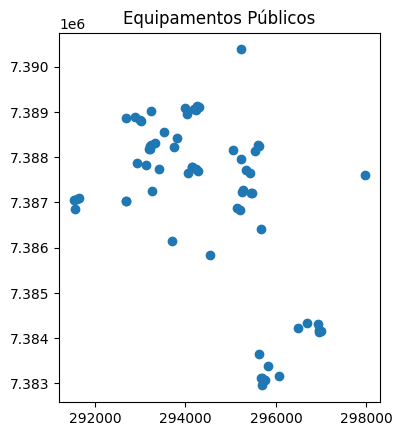

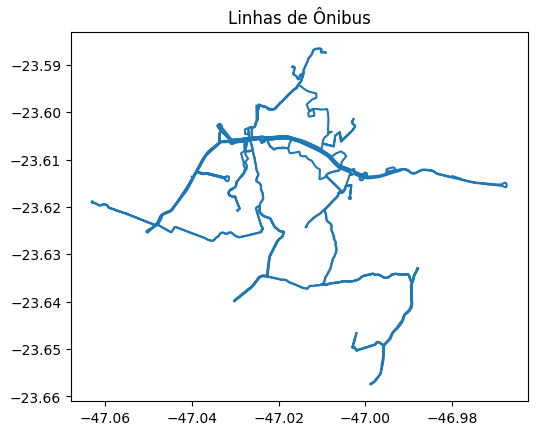

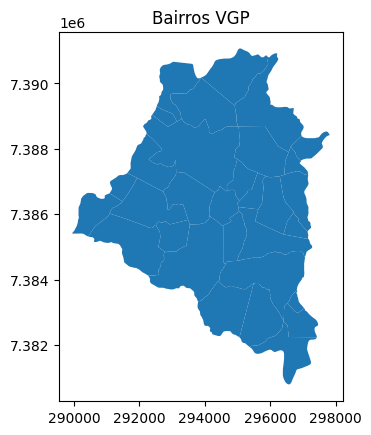

In [ ]:
import matplotlib.pyplot as plt

# Plotar os Linhas de ônibus
equip_publicos.plot()
plt.title('Equipamentos Públicos')
plt.show()

# Plotar os Linhas de ônibus
linhas_coletivo.plot()
plt.title('Linhas de Ônibus')
plt.show()

# Plotar os Linhas de ônibus
bairros_vgp.plot()
plt.title('Bairros VGP')
plt.show()

Verificação do sistema de coordenadas atual

In [ ]:
# Verifica o sistema de coordenadas atual
print("Equipamentos Públicos: ", equip_publicos.crs)
print("Linhas: ", linhas_coletivo.crs)
print("Bairros: ", bairros_vgp.crs)

Equipamentos Públicos:  EPSG:31983
Linhas:  EPSG:4674
Bairros:  EPSG:31983


Transformação de sistema de coordenadas

In [ ]:
# Garantir que os dados estejam no mesmo sistema de coordenadas
linhas_coletivo = linhas_coletivo.to_crs(bairros_vgp.crs)

In [ ]:
# Verifica o sistema de coordenadas atual
print("Equipamentos Públicos: ", equip_publicos.crs)
print("Linhas: ", linhas_coletivo.crs)
print("Bairros: ", bairros_vgp.crs)

Equipamentos Públicos:  EPSG:31983
Linhas:  EPSG:31983
Bairros:  EPSG:31983


Sobreposição

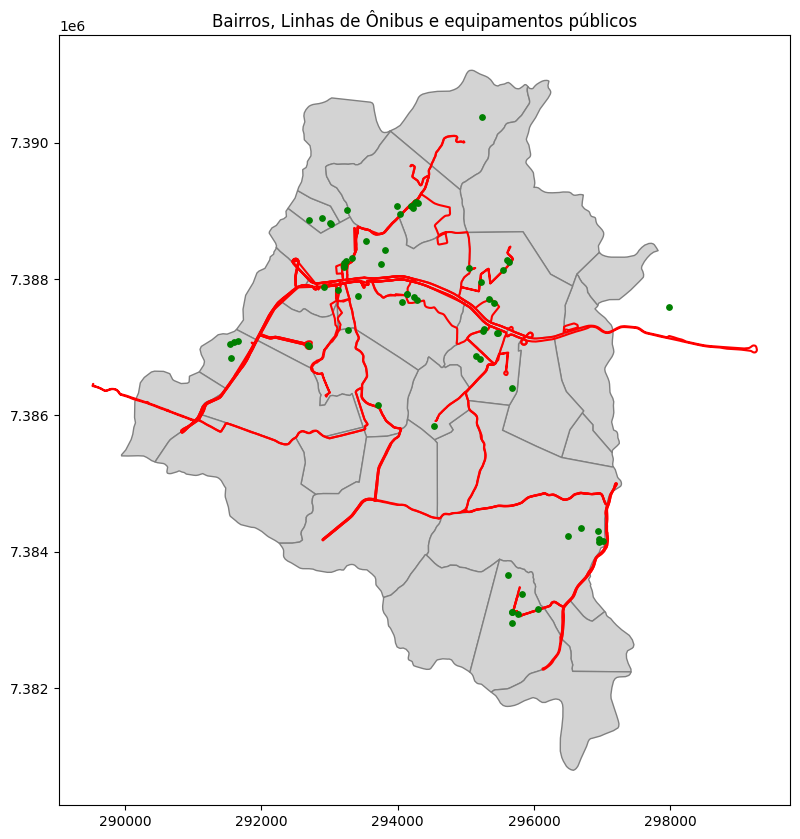

In [ ]:
# Plotar os bairros (polígonos) e os Linhas por cima
ax = bairros_vgp.plot(edgecolor='gray', facecolor='lightgray', figsize=(10,10), zorder=1)
linhas_coletivo.plot(ax=ax, color='red', markersize=1, zorder=2)
equip_publicos.plot(ax=ax, color='green', markersize=15, zorder=3)
plt.title('Bairros, Linhas de Ônibus e equipamentos públicos')
plt.show()

Buffer

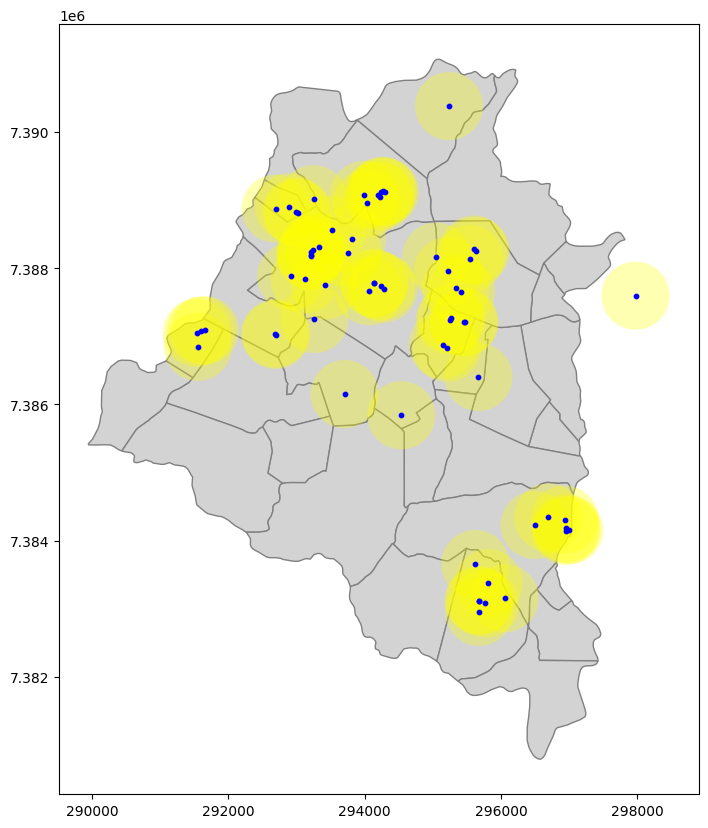

In [ ]:
# Criar buffer de 500 metros
buffers = equip_publicos.buffer(500)

# Criar um GeoDataFrame com os buffers (opcional)
buffers_gdf = gpd.GeoDataFrame(geometry=buffers, crs=equip_publicos.crs)

# Se quiser adicionar como coluna no original (projetado):
equip_publicos['buffer'] = buffers

# Plotar exemplo
ax = bairros_vgp.plot(edgecolor='gray', facecolor='lightgray', figsize=(10,10))
buffers_gdf.plot(ax=ax, color='yellow', alpha=0.3)
equip_publicos.plot(ax=ax, color='blue', markersize=10)
plt.show()

Junção (join)

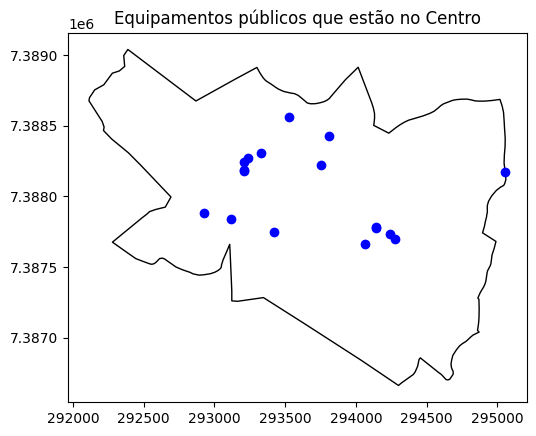

In [ ]:
# Selecionar um bairro (ex: "Centro")
bairro_centro = bairros_vgp[bairros_vgp['nome'] == 'Centro']

# Verificar quais equipamentos publicos intersectam esse bairro
equip_no_centro = equip_publicos[equip_publicos.intersects(bairro_centro.geometry.iloc[0])]

# Plotar
ax = bairro_centro.plot(facecolor='none', edgecolor='black')
equip_no_centro.plot(ax=ax, color='blue')
plt.title('Equipamentos públicos que estão no Centro')
plt.show()

3. Intersecção – quais linhas de ônibus passam dentro de uma determinada região?
Suponha que temos um arquivo linhas_onibus.shp (linhas) e queremos saber quais cruzam um bairro específico.

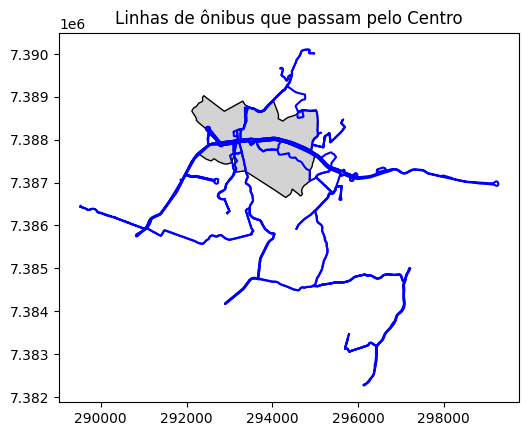

In [ ]:
# Selecionar um bairro (ex: "Centro")
bairro_centro = bairros_vgp[bairros_vgp['nome'] == 'Centro']

# Verificar quais linhas intersectam esse bairro
linhas_no_centro = linhas_coletivo[linhas_coletivo.intersects(bairro_centro.geometry.iloc[0])]

# Plotar
ax = bairro_centro.plot(facecolor='lightgray', edgecolor='black')
linhas_no_centro.plot(ax=ax, color='blue')
plt.title('Linhas de ônibus que passam pelo Centro')
plt.show()

## Exemplo 6


**Exemplo Prático Completo com Dados de Transporte**

Vamos simular um caso real: analisar a cobertura do transporte público por região da cidade. Usaremos dados hipotéticos de pontos de ônibus e limites de distritos.

Passo a passo:

* Carregar os distritos (polígonos).

* Carregar os pontos de ônibus.

* Calcular a densidade de pontos por km² em cada distrito.

* Visualizar em um mapa de densidade.

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt

In [ ]:
from google.colab import files
uploaded = files.upload()   # selecione os arquivos

Saving distritos.dbf to distritos (1).dbf
Saving distritos.prj to distritos (1).prj
Saving distritos.shp to distritos (1).shp
Saving distritos.shx to distritos (1).shx
Saving onibus.dbf to onibus (1).dbf
Saving onibus.prj to onibus (1).prj
Saving onibus.shp to onibus (1).shp
Saving onibus.shx to onibus (1).shx


In [ ]:
# 1. Carregar os dados
distritos = gpd.read_file('distritos.shp')
onibus = gpd.read_file('onibus.shp')

# 2. Garantir que ambos estejam na mesma projeção (usamos uma projeção em metros)
#    EPSG:31983 é adequado para o Brasil (SIRGAS 2000 / UTM zona 23S)
distritos = distritos.to_crs('EPSG:31983')
onibus = onibus.to_crs('EPSG:31983')

/tmp/ipykernel_3740/676299103.py:14: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()


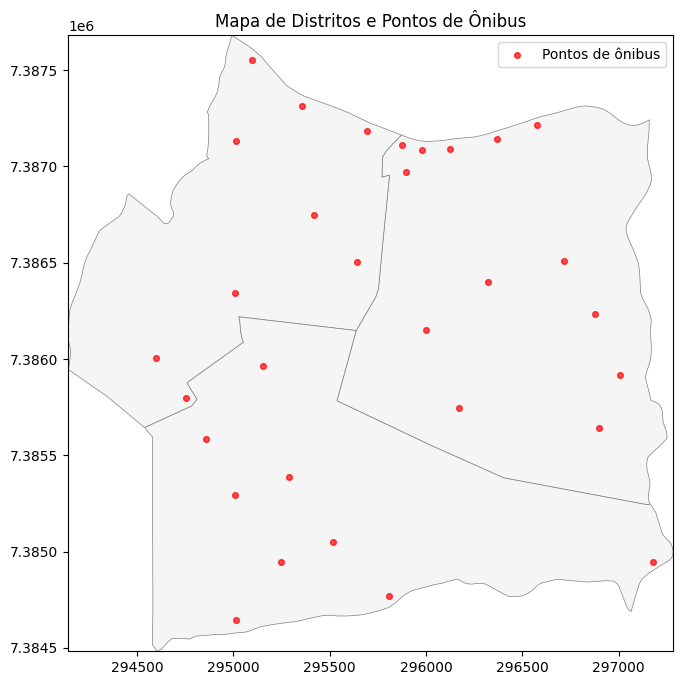

In [ ]:
# Visualização dos shapes

# A. Criar a figura e eixo
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

# B. Plotar os distritos (polígonos) com borda preta e preenchimento sem cor (transparente)
distritos.plot(ax=ax, edgecolor='gray', facecolor='whitesmoke', linewidth=0.5, label='Distritos')

# C. Plotar os pontos de ônibus como marcadores vermelhos
onibus.plot(ax=ax, color='red', markersize=17, label='Pontos de ônibus', alpha=0.7)

# D. Adicionar título e legenda
ax.set_title('Mapa de Distritos e Pontos de Ônibus')
ax.legend()

# E. Ajustar limites para focar na área de interesse (opcional)
#    Se quiser, pode usar o total_bounds dos distritos para definir os limites
xmin, ymin, xmax, ymax = distritos.total_bounds
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

# F. Mostrar o mapa
plt.show()

In [ ]:
# 3. Calcular a área de cada distrito em km²
distritos['area_km2'] = distritos.area / 1_000_000
# 4. Fazer a junção espacial: cada ponto de ônibus recebe o distrito onde está
pontos_com_distrito = gpd.sjoin(onibus, distritos, how='inner', predicate='within')

In [ ]:
# 5. Contar quantos pontos há em cada distrito
#    Nota: após o sjoin, a coluna com o nome do distrito pode vir com sufixo '_right'

#    Visualizar as colunas e renomear para simplificar
print("Colunas após sjoin:", pontos_com_distrito.columns.tolist())

Colunas após sjoin: ['codigo', 'nome_left', 'geometry', 'index_right', 'NM_MUN', 'AREA_KM2', 'nome_right', 'nome_od', 'cod', 'distritos', 'area_km2']


In [ ]:
# Vamos supor que a coluna que identifica o distrito chame-se 'nome' nos dois arquivos.
# Nesse caso, após o sjoin, teremos 'nome_left' (do ponto) e 'nome_right' (do distrito).

# Vamos renomear a coluna do distrito para 'distrito_nome' para facilitar.
pontos_com_distrito = pontos_com_distrito.rename(columns={'nome_right': 'distrito_nome'})

# Agora agrupamos pelo nome do distrito
contagem = pontos_com_distrito.groupby('distrito_nome').size().reset_index(name='total_onibus')

In [ ]:
print("Contagem de pontos de ônibus por distrito:")
print(contagem.sort_values('total_onibus', ascending=False))

Contagem de pontos de ônibus por distrito:
    distrito_nome  total_onibus
0  chacara_monica            13
1   jardim_europa             9
2   parque_afonso             9


In [ ]:
# 6. Juntar a contagem de volta à tabela dos distritos
distritos_completo = distritos.merge(contagem, left_on='nome', right_on='distrito_nome', how='left')
distritos_completo['total_onibus'] = distritos_completo['total_onibus'].fillna(0)

In [ ]:
# 7. Calcular a densidade (pontos por km²)
distritos_completo['densidade'] = distritos_completo['total_onibus'] / distritos_completo['area_km2']

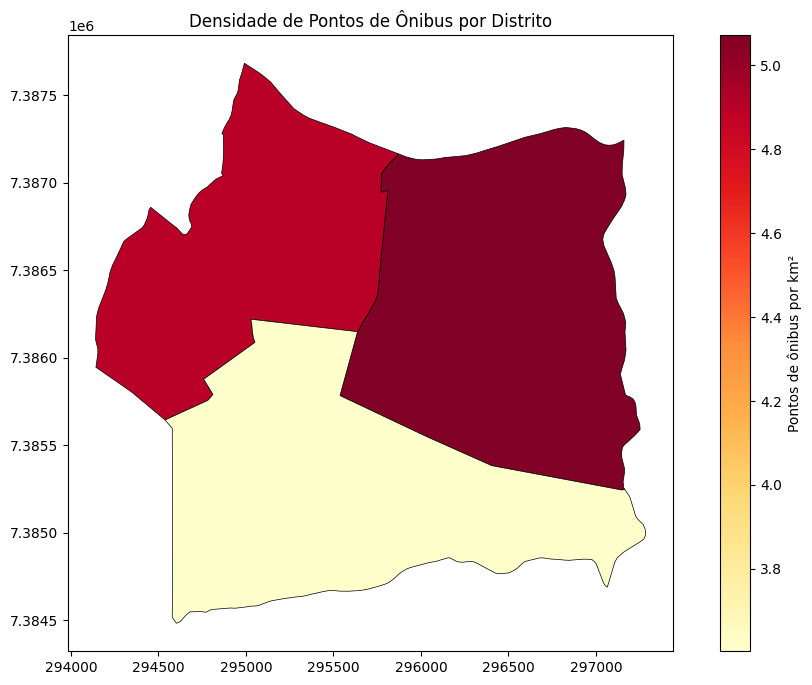

In [ ]:
# 8. Plotar o mapa
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
distritos_completo.plot(column='densidade', ax=ax, legend=True,
                        legend_kwds={'label': 'Pontos de ônibus por km²'},
                        cmap='YlOrRd', edgecolor='black', linewidth=0.5)
ax.set_title('Densidade de Pontos de Ônibus por Distrito')
plt.show()

## geobr

Introdução à Biblioteca geobr do INPE

A biblioteca geobr foi desenvolvida pelo Instituto Nacional de Pesquisas Espaciais (INPE) para facilitar o acesso a dados geoespaciais oficiais do Brasil. Ela oferece funções simples para baixar malhas municipais, estaduais, setores censitários, áreas urbanizadas, rodovias, ferrovias, aeroportos e muito mais – tudo diretamente de fontes como IBGE, IPEA, DNIT, ANAC, etc.

Para quem trabalha com análise de dados urbanos e transporte, o geobr é uma mão na roda: elimina a necessidade de procurar arquivos shapefile em sites espalhados e já entrega os dados prontos para uso no Python, integrados com geopandas (a biblioteca padrão para dados geoespaciais).

**Documentação:**

https://pypi.org/project/geobr/

In [ ]:
pip install geobr

O geobr depende do geopandas, que por sua vez pode exigir algumas bibliotecas de sistema (como GDAL). Em geral, a instalação via pip resolve, mas em alguns sistemas pode ser necessário instalar o geopandas separadamente ou usar o conda. Recomendamos criar um ambiente virtual e instalar:

In [ ]:
pip install geopandas geobr matplotlib

## Exemplo 7

Mapa de um Município com Estações de ônibus (dados fictícios)

Vamos baixar a malha do município de São Paulo (código IBGE 3550308) e plotar sobre ela alguns pontos que representam estações de ônibus ou metrô (criados aleatoriamente).

O objetivo é visualizar a distribuição espacial.

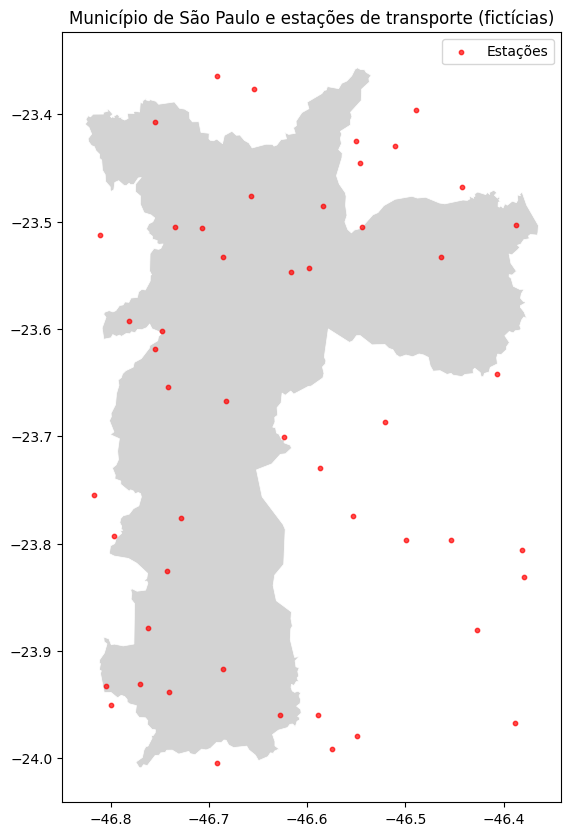

In [ ]:
import geobr
import geopandas as gpd
import matplotlib.pyplot as plt

# 1. Baixar a malha municipal de São Paulo
sp = geobr.read_municipality(code_muni=3550308, year=2020)

# 2. Criar dados fictícios de estações (coordenadas aproximadas)
# Vamos gerar alguns pontos dentro dos limites da cidade
bounds = sp.total_bounds  # (minx, miny, maxx, maxy)

import numpy as np
np.random.seed(42)
n_estacoes = 50
lon = np.random.uniform(bounds[0], bounds[2], n_estacoes)
lat = np.random.uniform(bounds[1], bounds[3], n_estacoes)

# Criar um GeoDataFrame com as estações
estacoes = gpd.GeoDataFrame(
    geometry=gpd.points_from_xy(lon, lat),
    crs="EPSG:4674"  # SIRGAS 2000 (mesmo CRS da malha)
)

# 3. Plotar
fig, ax = plt.subplots(figsize=(10, 10))
sp.plot(ax=ax, color='lightgray', edgecolor='white', linewidth=0.5)
estacoes.plot(ax=ax, color='red', markersize=10, alpha=0.7, label='Estações')
ax.set_title('Município de São Paulo e estações de transporte (fictícias)')
ax.legend()
plt.show()

## Exemplo 8

Relação entre Densidade Populacional e Proximidade de Estações de Metrô

In [ ]:
from google.colab import files
uploaded = files.upload()   # selecione os arquivos

# 1. Carregar os dados
metro = gpd.read_file('estacoes_metro.shp')

# 2. Garantir que ambos estejam na mesma projeção
metro = metro.to_crs('EPSG:4674')

Saving estacoes_metro.dbf to estacoes_metro (1).dbf
Saving estacoes_metro.prj to estacoes_metro (1).prj
Saving estacoes_metro.shp to estacoes_metro (1).shp
Saving estacoes_metro.shx to estacoes_metro (1).shx


In [ ]:
# 3. Baixar setores censitários de um município (ex: São Paulo)
setores_sp = geobr.read_census_tract(code_tract=3550308, year=2010)  # ano 2010

# 4. Simular uma coluna de população (valores aleatórios entre 100 e 1000)
np.random.seed(42)
setores_sp['populacao'] = np.random.randint(100, 1000, len(setores_sp))

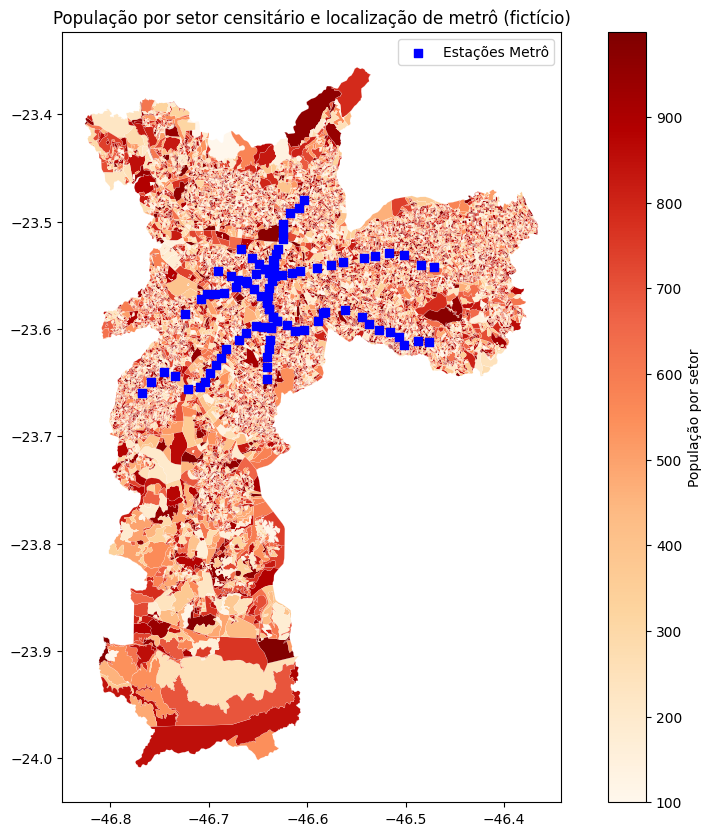

In [ ]:
# 5. Plotar um mapa de densidade da população e sobrepor as estações
fig, ax = plt.subplots(figsize=(12, 10))
setores_sp.plot(column='populacao', ax=ax, legend=True,
                legend_kwds={'label': 'População por setor'},
                cmap='OrRd', edgecolor='white', linewidth=0.1)
metro.plot(ax=ax, color='blue', markersize=30, marker='s', label='Estações Metrô')
ax.set_title('População por setor censitário e localização de metrô (fictício)')
ax.legend()
plt.show()

## Exemplo 9

Cobertura de Áreas Urbanizadas por Regiões Metropolitanas

/tmp/ipykernel_36328/3965607611.py:27: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
/tmp/ipykernel_36328/3965607611.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


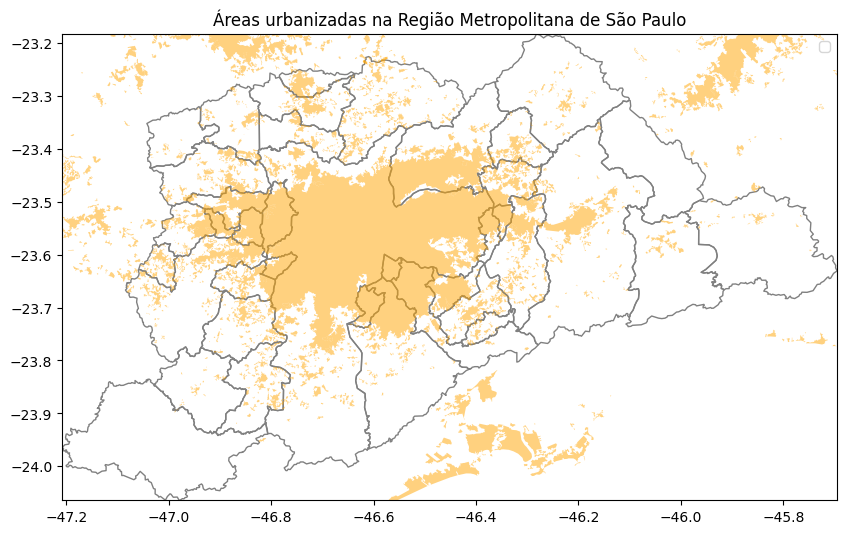

In [ ]:
import geobr
import matplotlib.pyplot as plt

# Baixar dados
areas_urbanas = geobr.read_urban_area(year=2015)
try:
    rm = geobr.read_metro_area(year=2018)
except:
    rm = geobr.read_metro_area(year=2015)

# Filtrar RM São Paulo
rm_sp = rm[rm['name_metro'] == 'RM São Paulo']  # ajuste se necessário

# Obter limites da RM
minx, miny, maxx, maxy = rm_sp.total_bounds

# Plot com zoom
fig, ax = plt.subplots(figsize=(10, 10))
rm_sp.plot(ax=ax, color='none', edgecolor='gray', linewidth=1, label='Limite RM São Paulo')
areas_urbanas.plot(ax=ax, color='orange', alpha=0.5, label='Áreas urbanizadas')

# Aplicar zoom
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

ax.set_title('Áreas urbanizadas na Região Metropolitana de São Paulo')
ax.legend()
plt.show()

# Exemplo 10

Carregar os municípios e estados do Brasil com a biblioteca geobr, contar  quantos municípios existem em cada estado e visualizar essa informação em um mapa

In [ ]:
import geopandas as gpd
import geobr
import matplotlib.pyplot as plt

In [ ]:
# 1. Carregar os municípios do Brasil

# A função read_municipality() retorna um GeoDataFrame com todos os municípios
municipios = geobr.read_municipality(year=2020)
print(municipios.head())

   code_muni              name_muni  code_state abbrev_state name_state  \
0  1100015.0  Alta Floresta D'oeste        11.0           RO   Rondônia   
1  1100023.0              Ariquemes        11.0           RO   Rondônia   
2  1100031.0                 Cabixi        11.0           RO   Rondônia   
3  1100049.0                 Cacoal        11.0           RO   Rondônia   
4  1100056.0             Cerejeiras        11.0           RO   Rondônia   

   code_region name_region                                           geometry  
0          1.0       Norte  MULTIPOLYGON (((-62.19465 -11.82746, -62.18945...  
1          1.0       Norte  MULTIPOLYGON (((-62.53648 -9.73222, -62.52765 ...  
2          1.0       Norte  MULTIPOLYGON (((-60.37119 -13.36655, -60.37661...  
3          1.0       Norte  MULTIPOLYGON (((-61.0008 -11.29737, -61.00103 ...  
4          1.0       Norte  MULTIPOLYGON (((-61.49976 -13.00525, -61.49426...  


Número de municípios: 5570
Index(['code_muni', 'name_muni', 'code_state', 'abbrev_state', 'name_state',
       'code_region', 'name_region', 'geometry'],
      dtype='object')


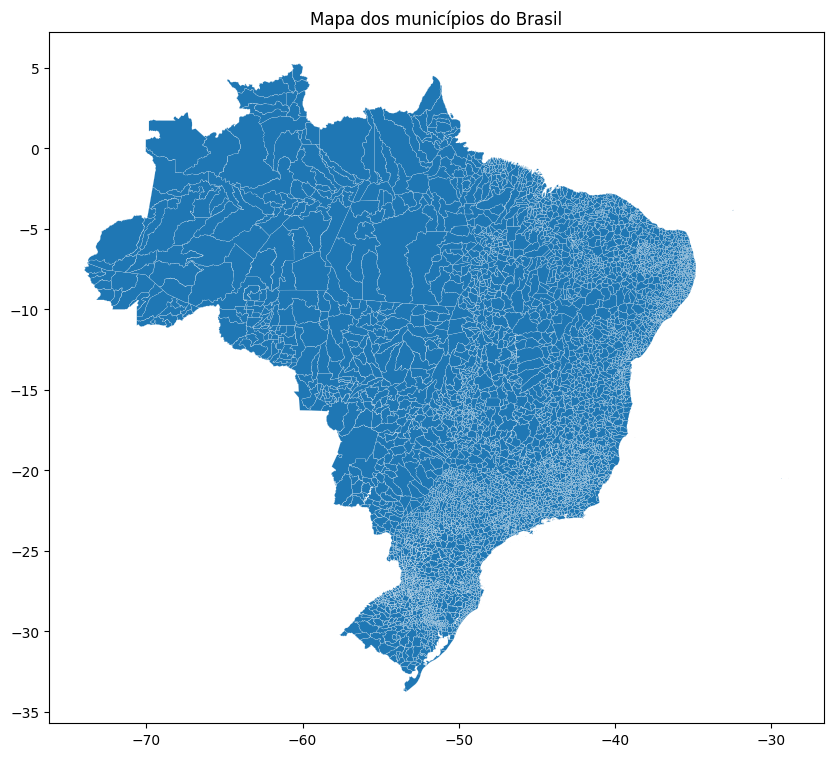

In [ ]:
# 2. Verificar informações básicas

# Quantos municípios?
print("Número de municípios:", len(municipios))

# Quais colunas existem?
print(municipios.columns)

# Plotar um mapa simples (pode demorar um pouco devido à quantidade de geometrias)
municipios.plot(figsize=(10,10), edgecolor='white', linewidth=0.1)
plt.title("Mapa dos municípios do Brasil")
plt.show()

In [ ]:
# 3. Carregar os estados (para podermos agrupar)

estados = geobr.read_state(year=2020)
print(estados.head())

   code_state abbrev_state name_state  code_region name_region  \
0        11.0           RO   Rondônia          1.0       Norte   
1        12.0           AC       Acre          1.0       Norte   
2        13.0           AM   Amazônas          1.0       Norte   
3        14.0           RR    Roraima          1.0       Norte   
4        15.0           PA       Pará          1.0       Norte   

                                            geometry  
0  MULTIPOLYGON (((-65.3815 -10.42907, -65.38013 ...  
1  MULTIPOLYGON (((-71.07772 -9.82774, -71.07817 ...  
2  MULTIPOLYGON (((-69.83766 -3.68659, -69.82555 ...  
3  MULTIPOLYGON (((-63.96008 2.47313, -63.96041 2...  
4  MULTIPOLYGON (((-51.43248 -0.47334, -51.42949 ...  


In [ ]:
# 4. Contar quantos municípios por estado

# Contagem de municípios por estado
contagem = municipios.groupby('code_state').size().reset_index(name='num_municipios')
print(contagem.head())

   code_state  num_municipios
0        11.0              52
1        12.0              22
2        13.0              62
3        14.0              15
4        15.0             144


In [ ]:
estados_com_contagem = estados.merge(contagem, left_on='code_state', right_on='code_state')
print(estados_com_contagem.head())

   code_state abbrev_state name_state  code_region name_region  \
0        11.0           RO   Rondônia          1.0       Norte   
1        12.0           AC       Acre          1.0       Norte   
2        13.0           AM   Amazônas          1.0       Norte   
3        14.0           RR    Roraima          1.0       Norte   
4        15.0           PA       Pará          1.0       Norte   

                                            geometry  num_municipios  
0  MULTIPOLYGON (((-65.3815 -10.42907, -65.38013 ...              52  
1  MULTIPOLYGON (((-71.07772 -9.82774, -71.07817 ...              22  
2  MULTIPOLYGON (((-69.83766 -3.68659, -69.82555 ...              62  
3  MULTIPOLYGON (((-63.96008 2.47313, -63.96041 2...              15  
4  MULTIPOLYGON (((-51.43248 -0.47334, -51.42949 ...             144  


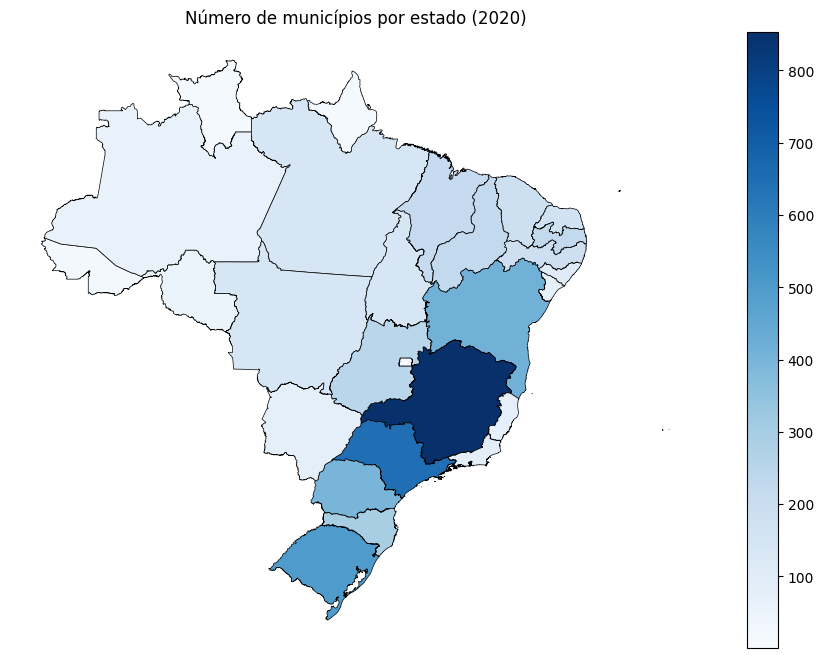

In [ ]:
# 5. Criar um mapa de densidade

fig, ax = plt.subplots(1, 1, figsize=(12, 8))
estados_com_contagem.plot(
    column='num_municipios',
    cmap='Blues',          # esquema de cores
    legend=True,
    edgecolor='black',
    linewidth=0.5,
    ax=ax
)
ax.set_title("Número de municípios por estado (2020)")
ax.axis('off')  # remove eixos
plt.show()

In [ ]:
# 6. Análise adicional – estado com mais e menos municípios

mais = estados_com_contagem.nlargest(1, 'num_municipios')
menos = estados_com_contagem.nsmallest(1, 'num_municipios')

print(f"Estado com mais municípios: {mais['abbrev_state'].values[0]} - {mais['num_municipios'].values[0]} municípios")
print(f"Estado com menos municípios: {menos['abbrev_state'].values[0]} - {menos['num_municipios'].values[0]} municípios")

Estado com mais municípios: MG - 853 municípios
Estado com menos municípios: DF - 1 municípios


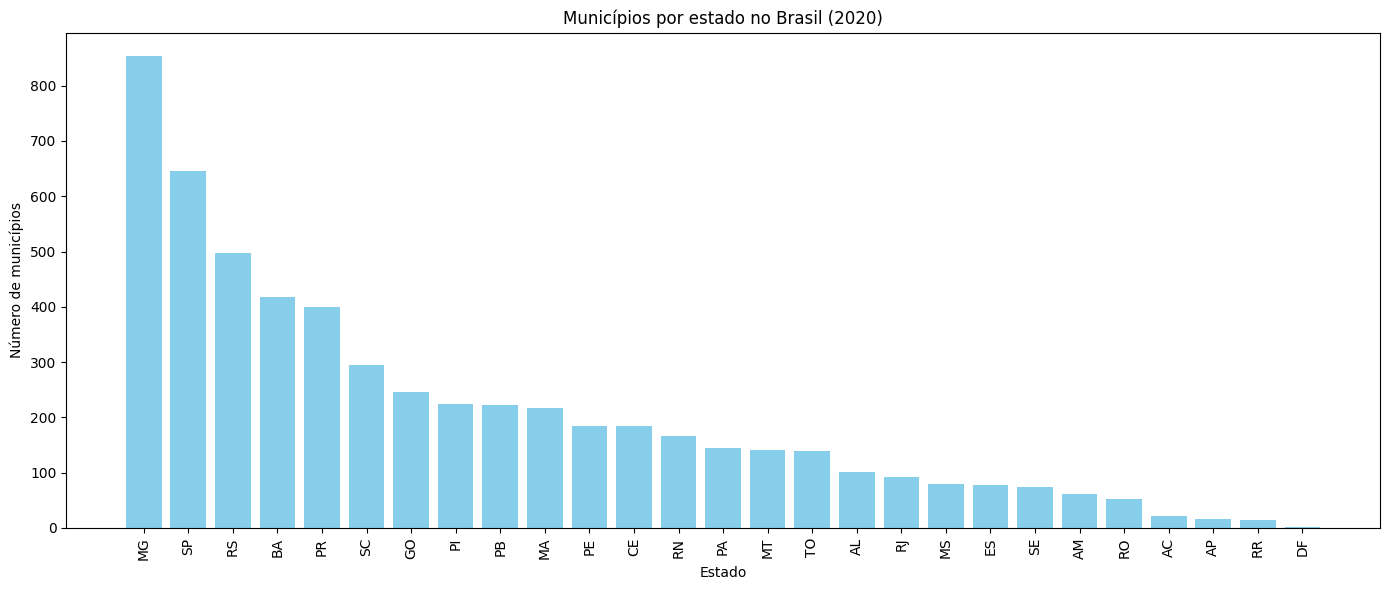

In [ ]:
# 7. Gráfico de barras

# Ordenar os estados pela quantidade de municípios
ordenados = estados_com_contagem.sort_values('num_municipios', ascending=False)

plt.figure(figsize=(14, 6))
plt.bar(ordenados['abbrev_state'], ordenados['num_municipios'], color='skyblue')
plt.xticks(rotation=90)
plt.xlabel('Estado')
plt.ylabel('Número de municípios')
plt.title('Municípios por estado no Brasil (2020)')
plt.tight_layout()
plt.show()

##OSMNX

OSMnx é uma biblioteca Python que permite baixar, modelar, analisar e visualizar redes de ruas e outras feições geoespaciais diretamente do OpenStreetMap (OSM) . Com apenas algumas linhas de código, é possível obter a malha viária completa de uma cidade, incluindo informações como sentido das vias, velocidades, tempos de viagem e muito mais.

Para análise de dados de transporte, o OSMnx é particularmente útil porque:

* Modela redes de diferentes modais: walking, driving, biking

* Calcula tempos de viagem baseados na velocidade das vias

* Permite análise de centralidade e resiliência da rede

* Integra-se perfeitamente com NetworkX para análises de grafos

**Documentação:**

https://osmnx.readthedocs.io/en/stable/

In [ ]:
!pip install osmnx matplotlib networkx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 4.1 MB/s eta 0:00:00


In [ ]:
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Ativar cache para melhor desempenho
ox.settings.use_cache = True

In [ ]:
city_name = "Gurarema, São Paulo, Brazil"

# baixar rede
G = ox.graph_from_place("Guararema, São Paulo, Brazil", network_type="drive")

# converter para GeoDataFrame
nodes, edges = ox.graph_to_gdfs(G)

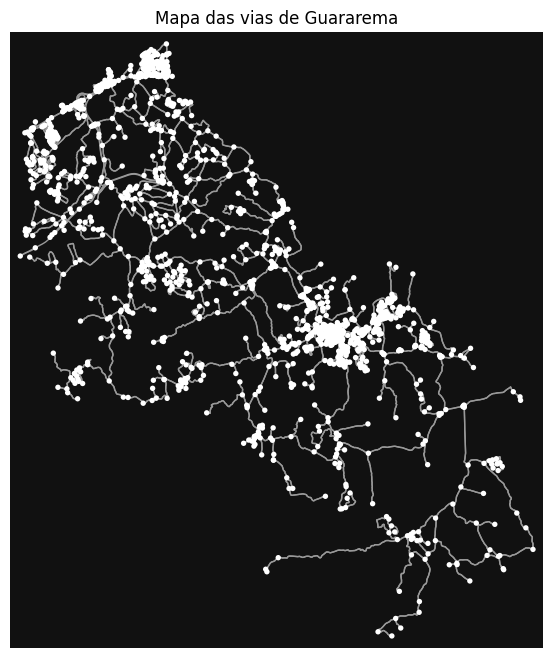

In [ ]:
city_name = "Guararema"
# Plot o grafo das vias
fig, ax = ox.plot_graph(G, show=False, close=False)
plt.title(f"Mapa das vias de {city_name}")
plt.show()

In [ ]:
nodes.to_file("nodes_guararema.shp")
edges.to_file("edges_guararema.shp")

/tmp/ipykernel_36328/2147049614.py:1: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  nodes.to_file("nodes_guararema.shp")
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'street_count' to 'street_cou'
  ogr_write(


In [ ]:
import zipfile
import glob

with zipfile.ZipFile("rede_guararema.zip", "w") as z:
    for file in glob.glob("nodes_guararema.*"):
        z.write(file)
    for file in glob.glob("edges_guararema.*"):
        z.write(file)

In [ ]:
from google.colab import files
files.download("rede_guararema.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Exercício 14

Exportar a rede viária de Vargem Grande Paulista.

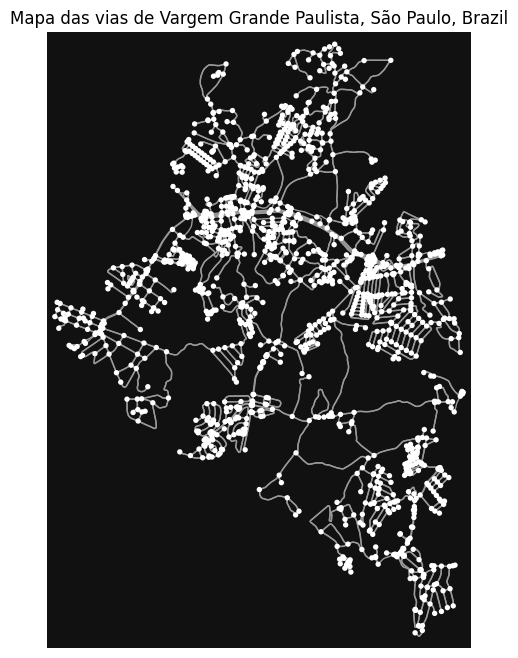

In [ ]:
# Define o nome da cidade
city_name = "Vargem Grande Paulista, São Paulo, Brazil"

# Baixa a rede viária para o modo "drive" (carros)
G = ox.graph_from_place(city_name, network_type="drive")

# Converte para GeoDataFrames (opcional, mas útil)
nodes, edges = ox.graph_to_gdfs(G)

# Plota o grafo
fig, ax = ox.plot_graph(G, show=False, close=False)
plt.title(f"Mapa das vias de {city_name}")
plt.show()

In [ ]:
nodes.to_file("nodes_vgp.shp")
edges.to_file("edges_vgp.shp")

import zipfile
import glob

with zipfile.ZipFile("rede_vgp.zip", "w") as z:
    for file in glob.glob("nodes_vgp.*"):
        z.write(file)
    for file in glob.glob("edges_vgp.*"):
        z.write(file)

from google.colab import files
files.download("rede_vgp.zip")

/tmp/ipykernel_36328/427907339.py:1: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  nodes.to_file("nodes_vgp.shp")
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'street_count' to 'street_cou'
  ogr_write(


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>